## 1. Setup and Installation

In [1]:
# Install required packages
!pip install -q diffusers transformers accelerate safetensors
!pip install -q invisible-watermark>=0.2.0
!pip install -q xformers
!pip install -q Pillow
!pip install -q opencv-python

# Install segmentation packages for automatic person masking
!pip install -q segment-anything
!pip install -q groundingdino-py

# Install R2/S3 and environment packages
!pip install -q boto3 python-dotenv requests

# Download SAM model checkpoint
import os
SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"
if not os.path.exists(SAM_CHECKPOINT):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O {SAM_CHECKPOINT}
    print("SAM model downloaded!")
else:
    print("SAM model already exists.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0+cpu requires torch==2.9.0, but you have torch 2.9.1 which is incompatible.
torchvision 0.24.0+cpu requires torch==2.9.0, but you have torch 2.9.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xformers 0.0.33.post2 requires torch==2.9.1, but you have torch 2.9.0 which is incompatible.
SAM model already exists.


In [2]:
import torch
import gc
import os
import json
import requests
import cv2
import boto3
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageFilter
import numpy as np

from diffusers import (
    StableDiffusionXLInpaintPipeline,
    DPMSolverMultistepScheduler,
)
from diffusers.utils import load_image, make_image_grid

# Segmentation imports
from segment_anything import sam_model_registry, SamPredictor
from transformers import pipeline, AutoProcessor, AutoModelForZeroShotObjectDetection

# Check GPU availability
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


CUDA available: False


## 2. Configuration

In [3]:
# =============================================================================
# CONFIGURATION - Modify these settings as needed
# =============================================================================

# Model settings
BASE_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"
REFINER_MODEL = "stabilityai/stable-diffusion-xl-refiner-1.0"

# LoRA settings - Update this path to your LoRA file
# Upload your LoRA to Colab or use a HuggingFace path
LORA_PATH = "/content/wesleygram-10.safetensors"  # Local path after upload
# Or use HuggingFace: LORA_PATH = "your-username/your-lora-repo"

LORA_SCALE = 0.85  # LoRA influence strength (0.0-1.0)

# Inference settings
RESOLUTION = 1024  # Output resolution (1024x1024)
NUM_INFERENCE_STEPS = 25  # 20-30 recommended
GUIDANCE_SCALE = 7.0  # ~7 recommended
HIGH_NOISE_FRAC = 0.8  # Base model handles 80%, refiner handles 20%

# Prompts
PROMPT = "photo of wesleykamau person male, realistic face, natural skin texture, matching lighting, photorealistic"
NEGATIVE_PROMPT = "blurry, distorted face, bad anatomy, extra eyes, unrealistic skin, extra limbs, deformed"

# Seed for reproducibility (-1 for random)
SEED = 42

# Person segmentation settings
SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"
SAM_MODEL_TYPE = "vit_h"
DETECTION_MODEL = "IDEA-Research/grounding-dino-tiny"  # For person detection
PERSON_DETECTION_THRESHOLD = 0.3  # Confidence threshold for person detection
MASK_EXPANSION_PIXELS = 10  # Expand mask slightly beyond detected person
MASK_FEATHER_RADIUS = 5  # Feather mask edges for smooth blending

# R2 Storage settings
R2_BUCKET_NAME = "instagram-profiles"
PROFILES_METADATA_URL = "https://raw.githubusercontent.com/your-repo/profiles_metadata.json"  # Optional: hosted metadata

# Device and dtype
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print(f"Device: {DEVICE}")
print(f"Dtype: {DTYPE}")

Device: cpu
Dtype: torch.float32


## 3. R2 Credentials Setup

Configure R2 credentials using either:
- **Google Colab**: Secrets (Settings → Secrets → Add new secret)
- **Local**: `.env` file with `python-dotenv`

Required secrets/env vars:
- `R2_ENDPOINT_URL` - Your R2 endpoint
- `R2_ACCESS_KEY_ID` - Access key
- `R2_SECRET_ACCESS_KEY` - Secret key
- `R2_BUCKET_NAME` (optional, defaults to `instagram-profiles`)

In [11]:
# =============================================================================
# R2 CREDENTIALS SETUP
# Supports both Google Colab secrets and local .env files
# =============================================================================

def load_credentials():
    """
    Load R2 credentials from Colab secrets or .env file.

    Returns:
        dict with r2_endpoint, r2_access_key, r2_secret_key, r2_bucket
    """
    credentials = {}

    # Try Google Colab secrets first
    try:
        from google.colab import userdata
        credentials['r2_endpoint'] = userdata.get('R2_ENDPOINT')
        credentials['r2_access_key'] = userdata.get('R2_ACCESS_KEY')
        credentials['r2_secret_key'] = userdata.get('R2_SECRET_KEY')
        credentials['r2_bucket'] = userdata.get('R2_BUCKET') or R2_BUCKET_NAME
        print(credentials)
        print("✓ Loaded credentials from Colab secrets")
    except (ImportError, Exception) as e:
        print(f"Colab secrets not available: {e}")

        # Fall back to .env file for local development
        try:
            from dotenv import load_dotenv
            load_dotenv()
            credentials['r2_endpoint'] = os.getenv('R2_ENDPOINT_URL') or os.getenv('R2_ENDPOINT')
            credentials['r2_access_key'] = os.getenv('R2_ACCESS_KEY_ID') or os.getenv('R2_ACCESS_KEY')
            credentials['r2_secret_key'] = os.getenv('R2_SECRET_ACCESS_KEY') or os.getenv('R2_SECRET_KEY')
            credentials['r2_bucket'] = os.getenv('R2_BUCKET') or os.getenv('R2_BUCKET_NAME') or R2_BUCKET_NAME
            print("✓ Loaded credentials from .env file", credentials)
        except ImportError:
            print("⚠ python-dotenv not installed, using environment variables only")
            credentials['r2_endpoint'] = os.getenv('R2_ENDPOINT_URL')
            credentials['r2_access_key'] = os.getenv('R2_ACCESS_KEY_ID')
            credentials['r2_secret_key'] = os.getenv('R2_SECRET_ACCESS_KEY')
            credentials['r2_bucket'] = os.getenv('R2_BUCKET_NAME') or R2_BUCKET_NAME

    # Validate credentials
    if not all([credentials.get('r2_endpoint'), credentials.get('r2_access_key'), credentials.get('r2_secret_key')]):
        missing = [k for k, v in credentials.items() if not v and k != 'r2_bucket']
        raise ValueError(f"Missing R2 credentials: {missing}\n"
                        "Please set them in Colab secrets or .env file.")

    return credentials

# Load credentials
r2_creds = load_credentials()
print(f"R2 Endpoint: {r2_creds['r2_endpoint']}")
print(f"R2 Bucket: {r2_creds['r2_bucket']}")

{'r2_endpoint': 'https://d0ca60ac6e1e2dcfa81185f2162df057.r2.cloudflarestorage.com', 'r2_access_key': 'c3dae2b82d7a02cc0b9fc2dbaf0c6841', 'r2_secret_key': 'b31fefc29f92e93204c54efae538ced2744b4afa773ca4fe94662fc855a0cb9c', 'r2_bucket': 'images-original'}
✓ Loaded credentials from Colab secrets
R2 Endpoint: https://d0ca60ac6e1e2dcfa81185f2162df057.r2.cloudflarestorage.com
R2 Bucket: images-original


In [14]:
# =============================================================================
# R2 CLIENT AND PROFILE FETCHING
# =============================================================================

class R2ProfileFetcher:
    """
    Fetches Instagram profile photos from R2 storage.
    Uses profiles_metadata.json to map usernames to R2 keys.
    """

    def __init__(self, credentials: dict, metadata_path: str = None):
        """
        Initialize R2 client and load metadata.

        Args:
            credentials: Dict with r2_endpoint, r2_access_key, r2_secret_key, r2_bucket
            metadata_path: Local path to profiles_metadata.json (optional)
        """
        self.bucket = credentials['r2_bucket']

        # Initialize S3 client for R2
        self.s3_client = boto3.client(
            's3',
            endpoint_url=credentials['r2_endpoint'],
            aws_access_key_id=credentials['r2_access_key'],
            aws_secret_access_key=credentials['r2_secret_key']
        )

        # Load profiles metadata
        self.metadata = self._load_metadata(metadata_path)
        self.profiles = self.metadata.get('profiles', {})

        # Build username lookup index
        self.username_to_id = {
            p['username'].lower(): pid
            for pid, p in self.profiles.items()
            if 'username' in p
        }

        print(f"✓ Loaded {len(self.profiles)} profiles from metadata")

    def _load_metadata(self, local_path: str = None) -> dict:
        """Load profiles_metadata.json from local file or R2."""

        # Try local file first
        if local_path and os.path.exists(local_path):
            print(f"Loading metadata from local file: {local_path}")
            with open(local_path, 'r', encoding='utf-8') as f:
                return json.load(f)

        # Try to fetch from R2
        try:
            print("Fetching metadata from R2...")
            response = self.s3_client.get_object(
                Bucket=self.bucket,
                Key='profiles_metadata.json'
            )
            return json.loads(response['Body'].read().decode('utf-8'))
        except Exception as e:
            print(f"Could not fetch from R2: {e}")

        # Try Colab upload as fallback
        try:
            from google.colab import files
            print("\nPlease upload profiles_metadata.json:")
            uploaded = files.upload()
            if uploaded:
                filename = list(uploaded.keys())[0]
                with open(f"/content/{filename}", 'r', encoding='utf-8') as f:
                    return json.load(f)
        except ImportError:
            pass

        raise FileNotFoundError("Could not load profiles_metadata.json")

    def get_profile_by_username(self, username: str) -> dict:
        """
        Get profile data by username.

        Args:
            username: Instagram username (case-insensitive)

        Returns:
            Profile dict with metadata and R2 key
        """
        username_lower = username.lower().lstrip('@')

        if username_lower not in self.username_to_id:
            raise ValueError(f"Username '{username}' not found in metadata.\n"
                           f"Available: {len(self.username_to_id)} profiles")

        profile_id = self.username_to_id[username_lower]
        return self.profiles[profile_id]

    def fetch_image(self, username: str, save_path: str = None) -> Image.Image:
        """
        Fetch profile image from R2 by username.

        Args:
            username: Instagram username
            save_path: Optional path to save the image locally

        Returns:
            PIL Image
        """
        profile = self.get_profile_by_username(username)
        r2_key = profile.get('original_image_r2_key')

        if not r2_key:
            raise ValueError(f"No R2 key found for {username}")

        print(f"Fetching {username} from R2: {r2_key}")

        # Fetch from R2
        response = self.s3_client.get_object(
            Bucket=self.bucket,
            Key=r2_key
        )

        image_bytes = response['Body'].read()
        image = Image.open(BytesIO(image_bytes)).convert('RGB')

        print(f"✓ Fetched image: {image.size[0]}x{image.size[1]}")

        # Save locally if path provided
        if save_path:
            os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
            image.save(save_path)
            print(f"✓ Saved to: {save_path}")

        return image

    def search_usernames(self, query: str, limit: int = 10) -> list[str]:
        """Search for usernames containing the query string."""
        query_lower = query.lower()
        matches = [
            uname for uname in self.username_to_id.keys()
            if query_lower in uname
        ]
        return sorted(matches)[:limit]

    def list_usernames(self, limit: int = 20) -> list[str]:
        """List available usernames."""
        return sorted(self.username_to_id.keys())[:limit]

# Initialize the R2 fetcher
# For local development, you can pass a local metadata path:
# r2_fetcher = R2ProfileFetcher(r2_creds, metadata_path="./profiles_metadata.json")
r2_fetcher = R2ProfileFetcher(r2_creds)

# Show some available usernames
print(f"\nSample usernames available:")
for uname in r2_fetcher.list_usernames(10):
    print(f"  - {uname}")

Fetching metadata from R2...
Could not fetch from R2: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.

Please upload profiles_metadata.json:


Saving profiles_metadata.json to profiles_metadata.json
✓ Loaded 3296 profiles from metadata

Sample usernames available:
  - 00dfrom614
  - 00piumlab
  - 018.018s
  - 05.wyatt
  - 070shake
  - 0800shygirl
  - 0_micachu_0
  - 0xkaii
  - 100gecs
  - 15harshit


---
# 🧪 TESTING SECTION: Mask Generation
---

This section allows you to test the person segmentation pipeline independently:
1. Enter an Instagram username
2. Fetch the profile photo from R2
3. Generate a person mask using ML
4. Display both the original image and the generated mask

Fetching profile photo for: @mel_early_
Fetching mel_early_ from R2: original/368049521_1766097965.jpg
✓ Fetched image: 1080x1080
✓ Saved to: /content/test_mel_early_.jpg

Profile Info:
  Full Name: Mel Earle
  Bio: my spirit animal is a goldfish cracker.           ...
  Followers: 1078
  Private: False

Original Image (1080x1080):


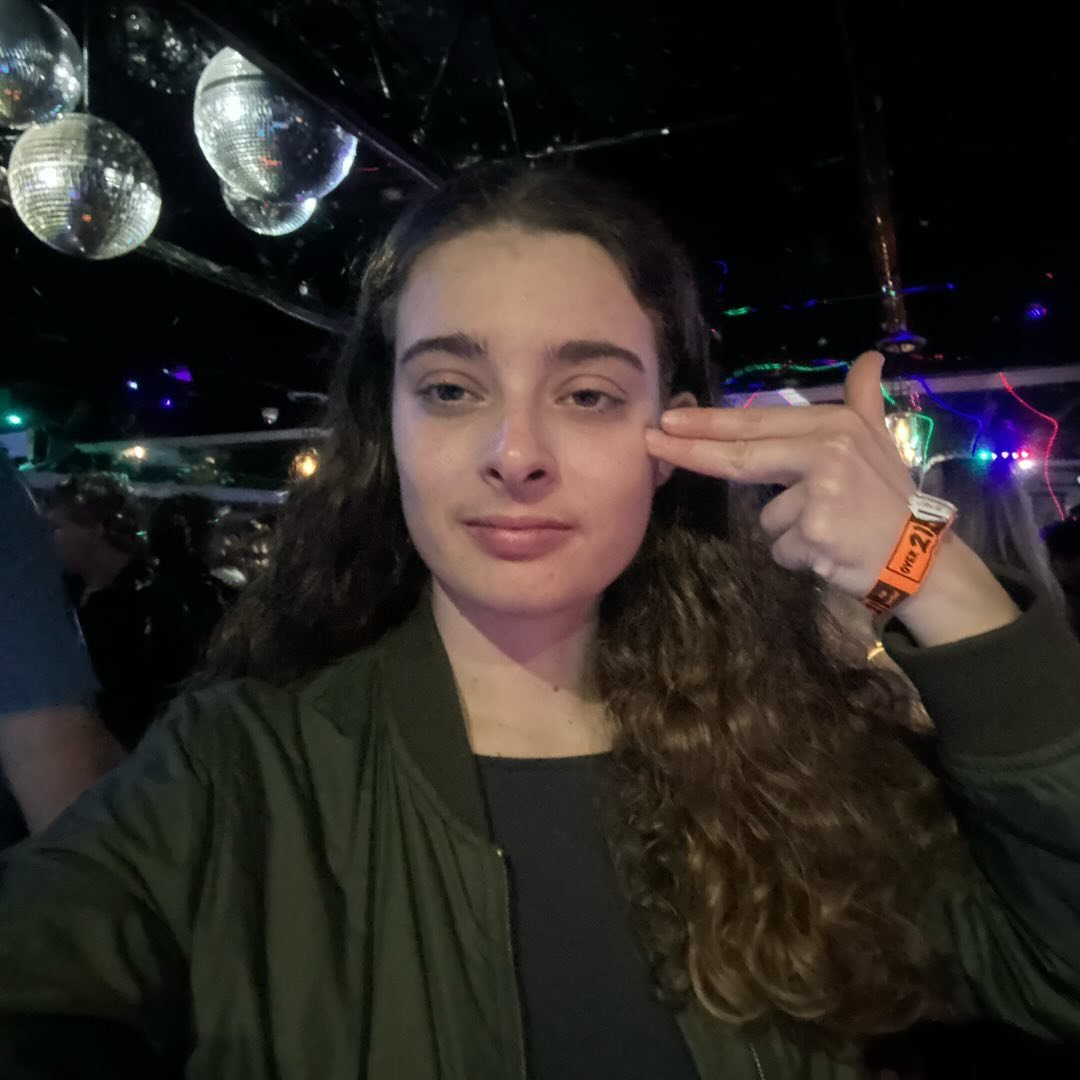

In [29]:
# =============================================================================
# TEST: Fetch profile image by username
# =============================================================================

# Enter the Instagram username to test
TEST_USERNAME = "mel_early_"  # @param {type:"string"}

# Fetch the image from R2
print(f"Fetching profile photo for: @{TEST_USERNAME}")
test_image_path = f"/content/test_{TEST_USERNAME}.jpg"

try:
    test_image = r2_fetcher.fetch_image(TEST_USERNAME, save_path=test_image_path)

    # Get profile metadata
    profile_data = r2_fetcher.get_profile_by_username(TEST_USERNAME)
    print(f"\nProfile Info:")
    print(f"  Full Name: {profile_data.get('full_name', 'N/A')}")
    print(f"  Bio: {profile_data.get('biography', 'N/A')[:50]}...")
    print(f"  Followers: {profile_data.get('follower_count', 'N/A')}")
    print(f"  Private: {profile_data.get('is_private', 'N/A')}")

    # Display the image
    print(f"\nOriginal Image ({test_image.size[0]}x{test_image.size[1]}):")
    display(test_image)

except Exception as e:
    print(f"❌ Error: {e}")
    test_image = None

In [24]:
import torch
import gc
import os
import json
import requests
import cv2
import boto3
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageFilter
import numpy as np

from diffusers import (
    StableDiffusionXLInpaintPipeline,
    DPMSolverMultistepScheduler,
)
from diffusers.utils import load_image, make_image_grid

# Segmentation imports
from segment_anything import sam_model_registry, SamPredictor
from transformers import pipeline, AutoProcessor, AutoModelForZeroShotObjectDetection

# Check GPU availability
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

class PersonSegmenterTest:
    """
    Lightweight person segmenter for testing mask generation.
    Uses Grounding DINO + SAM.
    """

    def __init__(
        self,
        sam_checkpoint: str,
        sam_model_type: str = "vit_h",
        detection_model: str = "IDEA-Research/grounding-dino-tiny",
        device: str = "cuda"
    ):
        self.device = device
        self._sam = None
        self._sam_predictor = None
        self._detector_processor = None
        self._detector_model = None
        self.sam_checkpoint = sam_checkpoint
        self.sam_model_type = sam_model_type
        self.detection_model_name = detection_model

    def _load_sam(self):
        """Lazy load SAM model."""
        if self._sam is None:
            print("Loading SAM model...")
            self._sam = sam_model_registry[self.sam_model_type](checkpoint=self.sam_checkpoint)
            self._sam.to(self.device)
            self._sam_predictor = SamPredictor(self._sam)
            print("✓ SAM loaded")

    def _load_detector(self):
        """Lazy load Grounding DINO."""
        if self._detector_model is None:
            print("Loading Grounding DINO...")
            self._detector_processor = AutoProcessor.from_pretrained(self.detection_model_name)
            self._detector_model = AutoModelForZeroShotObjectDetection.from_pretrained(
                self.detection_model_name
            ).to(self.device)
            print("✓ Grounding DINO loaded")

    def detect_people(
        self,
        image: Image.Image,
        threshold: float = 0.3
    ) -> list[list[float]]:
        """Detect people in image using Grounding DINO."""
        self._load_detector()

        text_prompt = "person. human. man. woman."

        inputs = self._detector_processor(
            images=image,
            text=text_prompt,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self._detector_model(**inputs)

        # Corrected call to post_process_grounded_object_detection
        results = self._detector_processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold,          # box_threshold
            threshold,          # text_threshold
            [image.size[::-1]]  # target_sizes (a list of image sizes)
        )[0]

        boxes = results["boxes"].cpu().numpy().tolist()
        scores = results["scores"].cpu().numpy().tolist()

        print(f"Detected {len(boxes)} person(s)")
        for i, (box, score) in enumerate(zip(boxes, scores)):
            print(f"  Person {i+1}: confidence={score:.2f}, box={[int(x) for x in box]}")

        return boxes

    def segment_from_boxes(
        self,
        image: Image.Image,
        boxes: list[list[float]],
        expansion_pixels: int = 10
    ) -> np.ndarray:
        """Generate segmentation mask using SAM."""
        self._load_sam()

        image_np = np.array(image)
        self._sam_predictor.set_image(image_np)

        combined_mask = np.zeros((image_np.shape[0], image_np.shape[1]), dtype=np.uint8)

        for box in boxes:
            x1, y1, x2, y2 = box
            x1 = max(0, x1 - expansion_pixels)
            y1 = max(0, y1 - expansion_pixels)
            x2 = min(image_np.shape[1], x2 + expansion_pixels)
            y2 = min(image_np.shape[0], y2 + expansion_pixels)

            box_np = np.array([[x1, y1, x2, y2]])

            masks, scores, _ = self._sam_predictor.predict(
                box=box_np,
                multimask_output=True
            )

            best_mask_idx = np.argmax(scores)
            mask = masks[best_mask_idx]
            combined_mask = np.maximum(combined_mask, (mask * 255).astype(np.uint8))

        return combined_mask

    def generate_mask(
        self,
        image: Image.Image,
        detection_threshold: float = 0.3,
        expansion_pixels: int = 10,
        feather_radius: int = 5
    ) -> Image.Image:
        """Full pipeline: detect people → segment → feather edges."""

        # Detect people
        boxes = self.detect_people(image, threshold=detection_threshold)

        if not boxes:
            print("⚠ No people detected!")
            return Image.new("L", image.size, 0)

        # Segment
        mask_np = self.segment_from_boxes(image, boxes, expansion_pixels)

        # Feather edges
        mask_pil = Image.fromarray(mask_np)
        if feather_radius > 0:
            mask_pil = mask_pil.filter(ImageFilter.GaussianBlur(radius=feather_radius))
            mask_np = np.array(mask_pil)
            mask_np = np.where(mask_np > 64, 255, 0).astype(np.uint8)
            mask_pil = Image.fromarray(mask_np)
            mask_pil = mask_pil.filter(ImageFilter.GaussianBlur(radius=max(1, feather_radius // 2)))

        return mask_pil

    def cleanup(self):
        """Free GPU memory."""
        del self._sam_predictor
        del self._sam
        del self._detector_model
        del self._detector_processor
        self._sam = None
        self._sam_predictor = None
        self._detector_model = None
        self._detector_processor = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print(f"✓ Cleaned up. VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# Initialize the test segmenter
print("Initializing segmenter (models load on first use)...")
test_segmenter = PersonSegmenterTest(
    sam_checkpoint=SAM_CHECKPOINT,
    sam_model_type=SAM_MODEL_TYPE,
    detection_model=DETECTION_MODEL,
    device=DEVICE
)
print("✓ Segmenter ready")

CUDA available: False
Initializing segmenter (models load on first use)...
✓ Segmenter ready


In [ ]:
# =============================================================================
# TEST: Generate and Display Mask
# =============================================================================

if test_image is not None:
    print(f"Generating person mask for @{TEST_USERNAME}...")
    print("-" * 50)

    # Generate mask
    test_mask = test_segmenter.generate_mask(
        test_image,
        detection_threshold=PERSON_DETECTION_THRESHOLD,
        expansion_pixels=MASK_EXPANSION_PIXELS,
        feather_radius=MASK_FEATHER_RADIUS
    )

    # Save mask
    test_mask_path = f"/content/test_{TEST_USERNAME}_mask.png"
    test_mask.save(test_mask_path)
    print(f"\n✓ Mask saved to: {test_mask_path}")

    # Create visualization: Original | Mask | Overlay
    print("\nResults (Original | Mask | Overlay):")

    # Create overlay visualization
    overlay = test_image.copy().convert("RGBA")
    mask_rgba = Image.new("RGBA", test_mask.size, (255, 0, 0, 0))
    mask_np = np.array(test_mask)
    mask_alpha = (mask_np > 128).astype(np.uint8) * 128  # Semi-transparent red
    mask_rgba_np = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
    mask_rgba_np[:, :, 0] = 255  # Red channel
    mask_rgba_np[:, :, 3] = mask_alpha  # Alpha channel
    mask_rgba = Image.fromarray(mask_rgba_np, mode="RGBA")
    overlay = Image.alpha_composite(overlay, mask_rgba).convert("RGB")

    # Display grid
    display(make_image_grid([test_image, test_mask.convert("RGB"), overlay], rows=1, cols=3))

    print(f"\n✓ Mask coverage: {np.mean(np.array(test_mask) > 128) * 100:.1f}% of image")
else:
    print("❌ No test image loaded. Run the previous cell first.")

Generating person mask for @mel_early_...
--------------------------------------------------


In [ ]:
# =============================================================================
# TEST: Interactive Testing - Try Multiple Usernames
# =============================================================================

def test_mask_for_username(username: str, display_results: bool = True):
    """
    Convenience function to test mask generation for any username.

    Args:
        username: Instagram username to test
        display_results: Whether to display the images

    Returns:
        Tuple of (image, mask) or None if failed
    """
    try:
        # Fetch image
        print(f"{'='*50}")
        print(f"Testing: @{username}")
        print(f"{'='*50}")

        image = r2_fetcher.fetch_image(username)

        # Generate mask
        mask = test_segmenter.generate_mask(
            image,
            detection_threshold=PERSON_DETECTION_THRESHOLD,
            expansion_pixels=MASK_EXPANSION_PIXELS,
            feather_radius=MASK_FEATHER_RADIUS
        )

        if display_results:
            # Create overlay
            overlay = image.copy().convert("RGBA")
            mask_np = np.array(mask)
            mask_rgba_np = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
            mask_rgba_np[:, :, 0] = 255
            mask_rgba_np[:, :, 3] = (mask_np > 128).astype(np.uint8) * 128
            mask_rgba = Image.fromarray(mask_rgba_np, mode="RGBA")
            overlay = Image.alpha_composite(overlay, mask_rgba).convert("RGB")

            display(make_image_grid([image, mask.convert("RGB"), overlay], rows=1, cols=3))
            print(f"Mask coverage: {np.mean(mask_np > 128) * 100:.1f}%")

        return image, mask

    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# Example: Test a few different usernames
# Uncomment to run:
# test_mask_for_username("15harshit")
# test_mask_for_username("some_other_user")

In [ ]:
# =============================================================================
# TEST: Search for usernames
# =============================================================================

# Search for usernames containing a string
search_query = "kai"  # @param {type:"string"}
print(f"Searching for usernames containing '{search_query}':")
matches = r2_fetcher.search_usernames(search_query, limit=15)
for match in matches:
    print(f"  - {match}")

In [ ]:
# =============================================================================
# TEST: Cleanup segmenter to free memory (optional)
# Run this before loading SDXL models if needed
# =============================================================================

# Uncomment to cleanup test segmenter:
# test_segmenter.cleanup()
# del test_segmenter
# print("✓ Test segmenter cleaned up")

---
# 🎨 MAIN PIPELINE: SDXL Inpainting
---

The sections below implement the full inpainting pipeline with SDXL base + refiner models.

In [ ]:
# =============================================================================
# Upload LoRA file (required for inpainting)
# =============================================================================

try:
    from google.colab import files
    print("Upload your LoRA file (.safetensors):")
    uploaded_lora = files.upload()

    if uploaded_lora:
        LORA_PATH = "/content/" + list(uploaded_lora.keys())[0]
        print(f"✓ LoRA path set to: {LORA_PATH}")
except ImportError:
    # Local development - use configured path
    print(f"Running locally - using LORA_PATH: {LORA_PATH}")
    if not os.path.exists(LORA_PATH):
        print(f"⚠ Warning: LoRA file not found at {LORA_PATH}")

## 4. Person Segmentation (Full Pipeline)

In [ ]:
def preprocess_image_and_mask(
    image_path: str,
    mask_path: str,
    target_size: int = 1024,
    feather_radius: int = 5
) -> tuple[Image.Image, Image.Image]:
    """
    Preprocess input image and mask for SDXL inpainting.

    Args:
        image_path: Path to the input image
        mask_path: Path to the mask image
        target_size: Target resolution (1024 for SDXL)
        feather_radius: Radius for edge feathering to avoid seams

    Returns:
        Tuple of (processed_image, processed_mask)

    Mask behavior:
        - White (255) = regions to regenerate (person to replace)
        - Black (0) = regions to preserve (background)
    """
    # Load images
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")  # Single channel grayscale

    original_size = image.size
    print(f"Original image size: {original_size}")
    print(f"Original mask size: {mask.size}")

    # Resize image to target resolution (maintain aspect ratio, center crop)
    # For best results with SDXL, use 1024x1024
    aspect = image.width / image.height

    if aspect > 1:  # Wider than tall
        new_width = int(target_size * aspect)
        new_height = target_size
    else:  # Taller than wide
        new_width = target_size
        new_height = int(target_size / aspect)

    # Resize with high-quality resampling
    image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

    # Center crop to target_size x target_size
    left = (new_width - target_size) // 2
    top = (new_height - target_size) // 2
    image = image.crop((left, top, left + target_size, top + target_size))

    # Resize mask to match image using NEAREST to preserve hard edges
    # Then apply the same crop
    mask = mask.resize((new_width, new_height), Image.Resampling.NEAREST)
    mask = mask.crop((left, top, left + target_size, top + target_size))

    # Apply slight feathering to mask edges to avoid seams
    if feather_radius > 0:
        from PIL import ImageFilter
        # Blur the mask slightly for soft edges
        mask_array = np.array(mask, dtype=np.float32)
        mask_pil = Image.fromarray(mask_array.astype(np.uint8))
        mask_blurred = mask_pil.filter(ImageFilter.GaussianBlur(radius=feather_radius))
        # Blend: keep hard mask in center, soft edges on boundary
        mask_array_blurred = np.array(mask_blurred, dtype=np.float32)
        # Threshold to maintain mostly binary mask with soft edges
        mask_array_blurred = np.clip(mask_array_blurred, 0, 255)
        mask = Image.fromarray(mask_array_blurred.astype(np.uint8))

    print(f"Processed image size: {image.size}")
    print(f"Processed mask size: {mask.size}")

    return image, mask

In [ ]:
# Initialize the full PersonSegmenter for the main pipeline
# (This is separate from the test segmenter)

segmenter = PersonSegmenter(
    sam_checkpoint=SAM_CHECKPOINT,
    sam_model_type=SAM_MODEL_TYPE,
    detection_model=DETECTION_MODEL,
    device=DEVICE
)

## 5. Fetch Image from R2 and Generate Mask

Enter a username to fetch their profile photo from R2 and generate a person mask.

In [ ]:
def preprocess_image_and_mask_from_pil(
    image: Image.Image,
    mask: Image.Image = None,
    segmenter = None,
    target_size: int = 1024,
    feather_radius: int = 5,
    detection_threshold: float = 0.3,
    expansion_pixels: int = 10
) -> tuple[Image.Image, Image.Image]:
    """
    Preprocess PIL image and mask for SDXL inpainting.

    If no mask is provided, automatically generates one using ML-based
    person segmentation (Grounding DINO + SAM).

    Args:
        image: PIL Image (already loaded)
        mask: PIL Image mask (optional - auto-generate if None)
        segmenter: PersonSegmenter instance for auto-mask generation
        target_size: Target resolution (1024 for SDXL)
        feather_radius: Radius for edge feathering to avoid seams
        detection_threshold: Confidence for person detection
        expansion_pixels: Expand mask beyond detected person

    Returns:
        Tuple of (processed_image, processed_mask)
    """
    original_size = image.size
    print(f"Original image size: {original_size}")

    # Generate or use provided mask
    if mask is None and segmenter is not None:
        print("Auto-generating person mask using ML segmentation...")
        mask = segmenter.generate_person_mask(
            image,
            detection_threshold=detection_threshold,
            expansion_pixels=expansion_pixels,
            feather_radius=feather_radius
        )
        print("Mask generated successfully!")
    elif mask is None:
        raise ValueError("Either mask or segmenter must be provided!")

    print(f"Mask size: {mask.size}")

    # Resize image to target resolution (maintain aspect ratio, center crop)
    aspect = image.width / image.height

    if aspect > 1:
        new_width = int(target_size * aspect)
        new_height = target_size
    else:
        new_width = target_size
        new_height = int(target_size / aspect)

    # Resize with high-quality resampling
    image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

    # Center crop
    left = (new_width - target_size) // 2
    top = (new_height - target_size) // 2
    image = image.crop((left, top, left + target_size, top + target_size))

    # Resize and crop mask to match
    mask = mask.resize((new_width, new_height), Image.Resampling.NEAREST)
    mask = mask.crop((left, top, left + target_size, top + target_size))

    print(f"Processed image size: {image.size}")
    print(f"Processed mask size: {mask.size}")

    return image, mask

In [ ]:
# =============================================================================
# Fetch image from R2 and generate mask
# =============================================================================

# Enter the username for inpainting
INPAINT_USERNAME = "0xkaii"  # @param {type:"string"}

print(f"Fetching profile photo for inpainting: @{INPAINT_USERNAME}")
print("=" * 50)

try:
    # Fetch from R2
    raw_image = r2_fetcher.fetch_image(INPAINT_USERNAME)

    # Preprocess and generate mask
    input_image, mask_image = preprocess_image_and_mask_from_pil(
        image=raw_image,
        mask=None,  # Auto-generate
        segmenter=segmenter,
        target_size=RESOLUTION,
        feather_radius=MASK_FEATHER_RADIUS,
        detection_threshold=PERSON_DETECTION_THRESHOLD,
        expansion_pixels=MASK_EXPANSION_PIXELS
    )

    # Display preprocessed images
    print("\nInput Image | Generated Mask:")
    display(make_image_grid([input_image, mask_image], rows=1, cols=2))

    # Save locally for reference
    input_image.save(f"/content/{INPAINT_USERNAME}_input.png")
    mask_image.save(f"/content/{INPAINT_USERNAME}_mask.png")
    print(f"\n✓ Saved input and mask to /content/")

except Exception as e:
    print(f"❌ Error: {e}")
    input_image = None
    mask_image = None

In [ ]:
# Free up segmentation model memory before loading SDXL
print("Cleaning up segmentation models to free VRAM...")
segmenter.cleanup()
del segmenter
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

## 5. Load Models

In [ ]:
def load_inpaint_pipelines(
    base_model: str,
    refiner_model: str,
    lora_path: str,
    lora_scale: float,
    device: str,
    dtype: torch.dtype
) -> tuple:
    """
    Load SDXL base and refiner inpainting pipelines with optimizations.

    Uses shared text_encoder_2 and vae between base and refiner to save memory.
    """
    print("Loading base inpainting model...")

    # Load base model
    base = StableDiffusionXLInpaintPipeline.from_pretrained(
        base_model,
        torch_dtype=dtype,
        variant="fp16",
        use_safetensors=True,
        add_watermarker=False,  # Disable watermarking
    )

    # Configure DPM++ scheduler for efficient sampling
    base.scheduler = DPMSolverMultistepScheduler.from_config(
        base.scheduler.config,
        algorithm_type="dpmsolver++",
        use_karras_sigmas=True,
    )

    print("Loading refiner model (sharing VAE and text_encoder_2)...")

    # Load refiner with shared components to save memory
    refiner = StableDiffusionXLInpaintPipeline.from_pretrained(
        refiner_model,
        text_encoder_2=base.text_encoder_2,
        vae=base.vae,
        torch_dtype=dtype,
        variant="fp16",
        use_safetensors=True,
        add_watermarker=False,
    )

    # Same scheduler for refiner
    refiner.scheduler = DPMSolverMultistepScheduler.from_config(
        refiner.scheduler.config,
        algorithm_type="dpmsolver++",
        use_karras_sigmas=True,
    )

    # Load LoRA weights into base model
    print(f"Loading LoRA from: {lora_path}")
    lora_file = Path(lora_path)

    if not lora_file.exists():
        raise FileNotFoundError(f"LoRA file not found: {lora_path}")

    # Load LoRA - works with both local files and HF repos
    base.load_lora_weights(
        str(lora_file.parent),
        weight_name=lora_file.name
    )

    # Also load LoRA into refiner for consistency
    refiner.load_lora_weights(
        str(lora_file.parent),
        weight_name=lora_file.name
    )

    print(f"LoRA loaded with scale: {lora_scale}")

    # Apply memory optimizations
    print("Applying optimizations...")

    if device == "cuda":
        # Move to GPU
        base.to(device)
        refiner.to(device)

        # Enable memory efficient attention
        try:
            base.enable_xformers_memory_efficient_attention()
            refiner.enable_xformers_memory_efficient_attention()
            print("✓ xFormers memory efficient attention enabled")
        except Exception as e:
            print(f"xFormers not available: {e}")

        # Enable CUDA optimizations
        torch.backends.cudnn.benchmark = True

        # Try torch.compile for additional speedup (PyTorch 2.x)
        try:
            base.unet = torch.compile(base.unet, mode="reduce-overhead", fullgraph=False)
            refiner.unet = torch.compile(refiner.unet, mode="reduce-overhead", fullgraph=False)
            print("✓ torch.compile enabled on UNet")
        except Exception as e:
            print(f"torch.compile not available: {e}")
    else:
        # CPU optimizations
        base.enable_attention_slicing()
        refiner.enable_attention_slicing()
        base.vae.enable_slicing()
        print("✓ Attention slicing enabled for CPU")

    print("Models loaded successfully!")

    return base, refiner

In [ ]:
# Clear any existing models from memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load the pipelines
base_pipe, refiner_pipe = load_inpaint_pipelines(
    base_model=BASE_MODEL,
    refiner_model=REFINER_MODEL,
    lora_path=LORA_PATH,
    lora_scale=LORA_SCALE,
    device=DEVICE,
    dtype=DTYPE
)

print(f"\nVRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB" if torch.cuda.is_available() else "")

## 6. Inpainting Function

In [ ]:
def inpaint_with_lora(
    base_pipe,
    refiner_pipe,
    image: Image.Image,
    mask: Image.Image,
    prompt: str,
    negative_prompt: str,
    num_inference_steps: int = 25,
    guidance_scale: float = 7.0,
    high_noise_frac: float = 0.8,
    lora_scale: float = 0.85,
    seed: int = -1,
    device: str = "cuda"
) -> Image.Image:
    """
    Perform SDXL inpainting using base + refiner ensemble of expert denoisers.

    Args:
        base_pipe: SDXL base inpainting pipeline
        refiner_pipe: SDXL refiner inpainting pipeline
        image: Input image (RGB)
        mask: Mask image (white=inpaint, black=preserve)
        prompt: Generation prompt (should include trigger token)
        negative_prompt: What to avoid
        num_inference_steps: Total denoising steps (20-30 recommended)
        guidance_scale: Classifier-free guidance (~7 recommended)
        high_noise_frac: Fraction of steps for base model (0.8 = 80%)
        lora_scale: LoRA influence strength
        seed: Random seed (-1 for random)
        device: Device to run on

    Returns:
        Inpainted image
    """
    # Set up generator for reproducibility
    if seed == -1:
        seed = torch.randint(0, 2**32, (1,)).item()

    generator = torch.Generator(device=device).manual_seed(seed)
    print(f"Using seed: {seed}")

    # Ensure mask is in correct format
    if mask.mode != "L":
        mask = mask.convert("L")

    with torch.inference_mode():
        # Stage 1: Base model handles high-noise denoising
        print(f"Stage 1: Base model ({int(high_noise_frac * 100)}% of denoising)...")

        latents = base_pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=image,
            mask_image=mask,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            denoising_end=high_noise_frac,
            output_type="latent",
            generator=generator,
            cross_attention_kwargs={"scale": lora_scale},
        ).images

        # Stage 2: Refiner handles low-noise denoising (detail enhancement)
        print(f"Stage 2: Refiner model ({int((1 - high_noise_frac) * 100)}% of denoising)...")

        result = refiner_pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=latents,
            mask_image=mask,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            denoising_start=high_noise_frac,
            generator=generator,
            cross_attention_kwargs={"scale": lora_scale},
        ).images[0]

    print("Inpainting complete!")
    return result, seed

## 8. Run Inpainting

In [ ]:
# Run the inpainting
if input_image is not None and mask_image is not None:
    print(f"Running inpainting for @{INPAINT_USERNAME}...")
    print("=" * 50)

    result_image, used_seed = inpaint_with_lora(
        base_pipe=base_pipe,
        refiner_pipe=refiner_pipe,
        image=input_image,
        mask=mask_image,
        prompt=PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        high_noise_frac=HIGH_NOISE_FRAC,
        lora_scale=LORA_SCALE,
        seed=SEED,
        device=DEVICE
    )

    # Display results
    print(f"\nResult (seed: {used_seed}):")
    print("Original | Mask | Inpainted:")
    display(make_image_grid([input_image, mask_image, result_image], rows=1, cols=3))
else:
    print("❌ No input image or mask. Run the 'Fetch Image from R2' cell first.")

## 9. Save Result

In [ ]:
# Save the result
if 'result_image' in dir() and result_image is not None:
    output_path = f"/content/{INPAINT_USERNAME}_inpainted_seed{used_seed}.png"
    result_image.save(output_path, "PNG")
    print(f"✓ Saved to: {output_path}")

    # Download the result
    try:
        from google.colab import files
        files.download(output_path)
    except ImportError:
        print("(Download not available in local environment)")
else:
    print("❌ No result to save. Run inpainting first.")

## 10. Batch Processing (Optional)

Process multiple profiles from R2 with automatic mask generation.

In [ ]:
def batch_inpaint_from_r2(
    r2_fetcher,
    base_pipe,
    refiner_pipe,
    usernames: list[str],
    output_dir: str,
    prompt: str,
    negative_prompt: str,
    sam_checkpoint: str = SAM_CHECKPOINT,
    sam_model_type: str = SAM_MODEL_TYPE,
    detection_model: str = DETECTION_MODEL,
    **kwargs
) -> list[dict]:
    """
    Batch process multiple profiles from R2 with automatic person segmentation.

    Args:
        r2_fetcher: R2ProfileFetcher instance
        base_pipe: SDXL base inpainting pipeline
        refiner_pipe: SDXL refiner pipeline
        usernames: List of Instagram usernames to process
        output_dir: Directory to save results
        prompt: Generation prompt
        negative_prompt: Negative prompt
        **kwargs: Additional args for inpaint_with_lora

    Returns:
        List of result dicts with username, paths, and status
    """
    os.makedirs(output_dir, exist_ok=True)

    # Load segmentation models for batch
    print("Loading segmentation models for batch processing...")
    batch_segmenter = PersonSegmenterTest(
        sam_checkpoint=sam_checkpoint,
        sam_model_type=sam_model_type,
        detection_model=detection_model,
        device=kwargs.get('device', 'cuda')
    )

    results = []

    for i, username in enumerate(usernames):
        print(f"\n{'='*60}")
        print(f"Processing {i+1}/{len(usernames)}: @{username}")
        print(f"{'='*60}")

        result_entry = {
            'username': username,
            'status': 'pending',
            'input_path': None,
            'mask_path': None,
            'output_path': None,
            'error': None
        }

        try:
            # Fetch image from R2
            raw_image = r2_fetcher.fetch_image(username)

            # Generate mask
            mask = batch_segmenter.generate_mask(
                raw_image,
                detection_threshold=kwargs.get('detection_threshold', 0.3),
                expansion_pixels=kwargs.get('expansion_pixels', 10),
                feather_radius=kwargs.get('feather_radius', 5)
            )

            # Preprocess
            image, mask = preprocess_image_and_mask_from_pil(
                image=raw_image,
                mask=mask,
                target_size=kwargs.get('resolution', 1024)
            )

            # Save input and mask
            input_path = f"{output_dir}/{username}_input.png"
            mask_path = f"{output_dir}/{username}_mask.png"
            image.save(input_path)
            mask.save(mask_path)
            result_entry['input_path'] = input_path
            result_entry['mask_path'] = mask_path

            # Inpaint
            inpainted, seed = inpaint_with_lora(
                base_pipe, refiner_pipe,
                image, mask,
                prompt, negative_prompt,
                **kwargs
            )

            # Save result
            output_path = f"{output_dir}/{username}_inpainted_seed{seed}.png"
            inpainted.save(output_path)
            result_entry['output_path'] = output_path
            result_entry['status'] = 'success'
            result_entry['seed'] = seed

            print(f"✓ Saved: {output_path}")

        except Exception as e:
            result_entry['status'] = 'failed'
            result_entry['error'] = str(e)
            print(f"❌ Failed: {e}")

        results.append(result_entry)

        # Clear cache between images
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Cleanup segmentation models
    batch_segmenter.cleanup()
    del batch_segmenter
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Summary
    success = sum(1 for r in results if r['status'] == 'success')
    failed = sum(1 for r in results if r['status'] == 'failed')

    print(f"\n{'='*60}")
    print(f"Batch complete!")
    print(f"  ✓ Success: {success}")
    print(f"  ✗ Failed: {failed}")
    print(f"{'='*60}")

    return results

In [ ]:
# =============================================================================
# Example: Batch process multiple usernames from R2
# =============================================================================

# List of usernames to process
BATCH_USERNAMES = [
    "0xkaii",
    "15harshit",
    # Add more usernames here
]

# Uncomment to run batch processing:
# batch_results = batch_inpaint_from_r2(
#     r2_fetcher=r2_fetcher,
#     base_pipe=base_pipe,
#     refiner_pipe=refiner_pipe,
#     usernames=BATCH_USERNAMES,
#     output_dir="/content/batch_outputs",
#     prompt=PROMPT,
#     negative_prompt=NEGATIVE_PROMPT,
#     num_inference_steps=NUM_INFERENCE_STEPS,
#     guidance_scale=GUIDANCE_SCALE,
#     high_noise_frac=HIGH_NOISE_FRAC,
#     lora_scale=LORA_SCALE,
#     seed=-1,  # Random seed for each
#     device=DEVICE,
#     detection_threshold=PERSON_DETECTION_THRESHOLD,
#     expansion_pixels=MASK_EXPANSION_PIXELS,
#     feather_radius=MASK_FEATHER_RADIUS
# )

# Download all results as zip:
# import shutil
# shutil.make_archive("/content/batch_results", "zip", "/content/batch_outputs")
# files.download("/content/batch_results.zip")

## 11. Experiment with Different Settings

In [ ]:
# Interactive experimentation - modify these and re-run
EXPERIMENT_PROMPT = "photo of wesleykamau person male, realistic face, natural skin texture, matching lighting, photorealistic"
EXPERIMENT_NEG = "blurry, distorted face, bad anatomy, extra eyes, unrealistic skin"
EXPERIMENT_STEPS = 30
EXPERIMENT_GUIDANCE = 7.5
EXPERIMENT_LORA_SCALE = 0.9
EXPERIMENT_SEED = -1  # Random

if 'input_image' in dir() and 'mask_image' in dir():
    exp_result, exp_seed = inpaint_with_lora(
        base_pipe, refiner_pipe,
        input_image, mask_image,
        EXPERIMENT_PROMPT, EXPERIMENT_NEG,
        num_inference_steps=EXPERIMENT_STEPS,
        guidance_scale=EXPERIMENT_GUIDANCE,
        high_noise_frac=0.8,
        lora_scale=EXPERIMENT_LORA_SCALE,
        seed=EXPERIMENT_SEED,
        device=DEVICE
    )

    print(f"\nExperiment result (seed: {exp_seed}):")
    display(exp_result)

## 12. Memory Cleanup

In [ ]:
# Clean up GPU memory when done
def cleanup():
    global base_pipe, refiner_pipe

    if 'base_pipe' in dir():
        del base_pipe
    if 'refiner_pipe' in dir():
        del refiner_pipe

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

    print("Cleanup complete!")

# Uncomment to run cleanup
# cleanup()

---

## Tips for Best Results

### R2 Integration
- **Colab secrets**: Add `R2_ENDPOINT_URL`, `R2_ACCESS_KEY_ID`, `R2_SECRET_ACCESS_KEY` in Settings → Secrets
- **Local development**: Create a `.env` file with the same variables
- **Metadata**: The `profiles_metadata.json` maps usernames to R2 keys

### Automatic Person Segmentation
- **Detection threshold**: Lower (0.2) = more sensitive, may include false positives. Higher (0.4) = stricter
- **Expansion pixels**: Increase (15-20) if masks are too tight around the person
- **Feather radius**: Higher values (7-10) create softer edges for better blending

### Inpainting
1. **Prompt Engineering**: Always start with your trigger token (`wesleykamau person male`)
2. **LoRA Scale**: Start at 0.8-0.9, reduce if results are too stylized
3. **Guidance Scale**: 7-8 works well for realistic results
4. **Steps**: 25-30 provides good quality without excessive compute
5. **Seed**: Use fixed seeds to iterate on prompts, random for variety

### Models Used
- **Grounding DINO**: Zero-shot object detection for finding people in images
- **SAM (Segment Anything)**: Precise segmentation masks from bounding boxes
- **SDXL Base**: High-quality image generation
- **SDXL Refiner**: Detail enhancement using ensemble of expert denoisers

### Memory Optimization
- Segmentation models are unloaded after mask generation to free VRAM for SDXL
- Base and Refiner share VAE and text_encoder_2 to reduce memory usage
- Use `enable_model_cpu_offload()` if running out of VRAM

### Testing Section
Use the 🧪 Testing Section cells to quickly test mask generation on different usernames
without running the full SDXL pipeline.